<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn8fmnist_aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# FashionMnist dataset에 이미지 보강 후 분류
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

np.random.seed(0)
tf.random.set_seed(0)

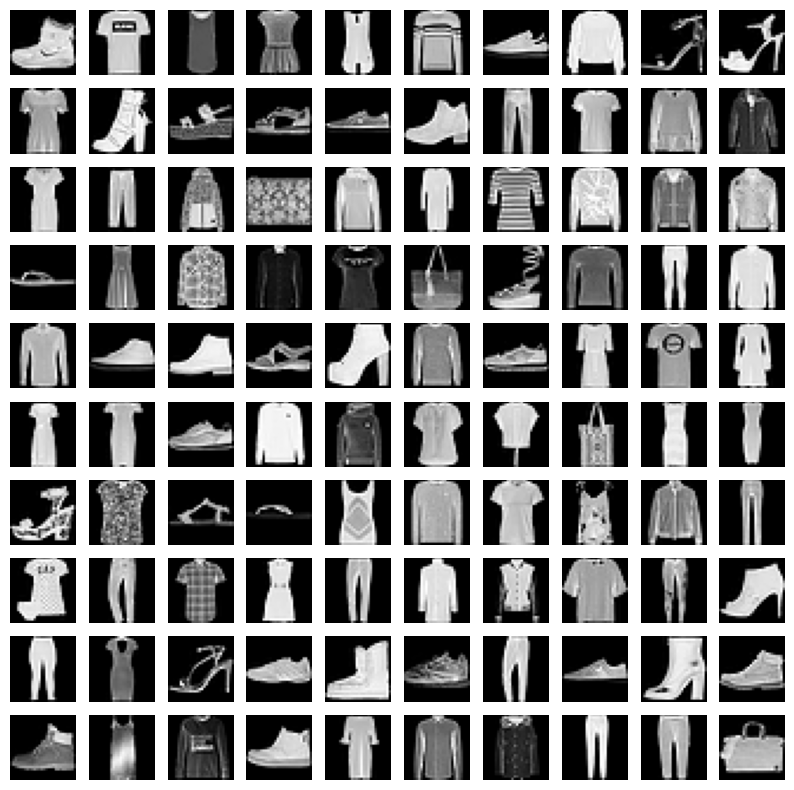

In [9]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
# print(x_train[0])

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
# print(y_test[:5])

# 시각화
plt.figure(figsize=(10, 10))
for c in range(100):
  plt.subplot(10, 10, c + 1)
  plt.axis('off')
  plt.imshow(x_train[c].reshape(28, 28), cmap='gray')
plt.show()

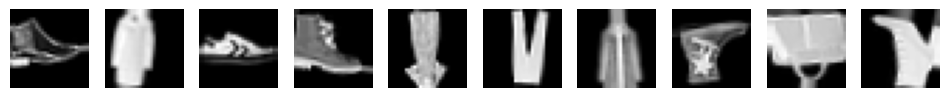

(90000, 28, 28, 1)
(120000, 28, 28, 1)


In [11]:
# 이미지 보강
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_generate = ImageDataGenerator(
    rotation_range = 10,    # 랜덤하게 이미지 회전
    zoom_range = 0.1,       # 확대 / 축소
    shear_range = 0.5,      # 축 중심 전환 (모양 기울이기)
    width_shift_range = 0.1,  # 평행 이동 (수평)
    height_shift_range = 0.1,  # 평행 이동 (수직)
    horizontal_flip = True,   # 수평 전환
    vertical_flip = True      # 수직 전환
)

augment_size = 30000
randidx = np.random.randint(x_train.shape[0], size=augment_size)
x_augment = x_train[randidx].copy()
y_augment = y_train[randidx].copy()

gen = img_generate.flow(
    x_augment, y_augment, batch_size=augment_size, shuffle=False
)

x_augment, y_augment = next(gen)

# 증강 이미지 일부 시각화
plt.figure(figsize=(12, 3))
for i in range(10):
  plt.subplot(1, 10, i + 1)
  plt.imshow(x_augment[i].reshape(28, 28), cmap='gray')
  label = np.argmax(y_augment[i])
  plt.axis('off')
plt.show()

# 원본에 합치기
print(x_train.shape)    # (60000, 28, 28, 1)
x_train = np.concatenate([x_train, x_augment], axis=0)
y_train = np.concatenate([y_train, y_augment], axis=0)
print(x_train.shape)    # (90000, 28, 28, 1)

In [12]:
# 신경망(네트워크) 설정
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(rate=0.1),

    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(rate=0.1),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(rate=0.2),

    tf.keras.layers.Dense(units=10, activation='softmax')
])

print(model.summary())

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

MODEL_DIR = './fmnist/'
if not os.path.exists(MODEL_DIR):
  os.mkdir(MODEL_DIR)
modelpath = './fmnist/{epoch:02d}_{val_loss:.4f}.keras'
checkpoint = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=0, save_best_only=True)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(x_train, y_train, validation_split=0.2, epochs=100, batch_size=200, verbose=1, callbacks=[checkpoint, es])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,994 (867.16 KB)

 Trainable params: 221,994 (867.16 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6763 - loss: 0.8907 - val_accuracy: 0.7039 - val_loss: 0.8031
Epoch 2/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7901 - loss: 0.5777 - val_accuracy: 0.7414 - val_loss: 0.6918
Epoch 3/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8154 - loss: 0.5102 - val_accuracy: 0.7616 - val_loss: 0.6270
Epoch 4/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8314 - loss: 0.4652 - val_accuracy: 0.7771 - val_loss: 0.5996
Epoch 5/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8428 - loss: 0.4352 - val_accuracy: 0.7781 - val_loss: 0.5951
Epoch 6/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8523 - loss: 0.4087 - val_accuracy: 0.7952 - val_loss: 0.5518
Epoch 7/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8606 - loss: 0.3902 - val_accuracy: 0.8037 - val_loss: 0.5300
Epoch 8/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8652 - loss: 0.3728 - va

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9179 - loss: 0.2357
test acc : 0.9179


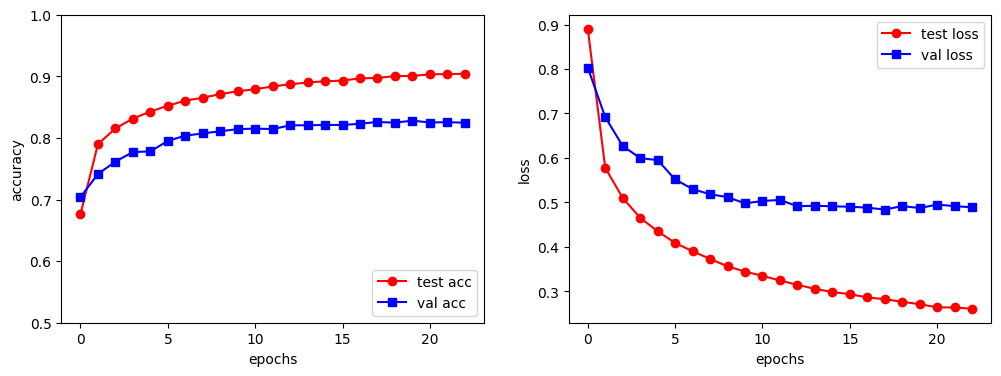

In [13]:
# test 정확도
print('test acc : %.4f'%(model.evaluate(x_test, y_test)[1]))

# 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', c='red', label='test acc')
plt.plot(history.history['val_accuracy'], marker='s', c='blue', label='val acc')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.ylim(0.5, 1)
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', c='red', label='test loss')
plt.plot(history.history['val_loss'], marker='s', c='blue', label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(loc='upper right')

plt.show()